In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from itertools import combinations

In [5]:

# Load data
input_path = "../data/processed/BRFSS_Diabetes_MedicalOnly.csv"
output_path = "../data/processed/BRFSS_Diabetes_Relevant_Features.csv"

df = pd.read_csv(input_path)

selected_features = [
    # Numerical
    "chronic_conditions_standard",
    "age_cat",
    "BMI",
    "cholesterol_screening_score",
    "care_access_score",
    "total_activity_duration",
    "total_fv_servings",

    # Binary
    "has_high_bp",
    "has_high_cholesterol",
    "had_cvd",
    "has_arthritis",
    "low_income",
    "college_graduate",
    "heavy_drinker",
    "is_female"
]

target = "has_diabetes"


# Ensure all selected features and target exist
available_features = [col for col in selected_features if col in df.columns]
missing_features = [col for col in selected_features if col not in df.columns]
if missing_features:
    print(f"Warning: The following features are not in the dataset and will be skipped: {missing_features}")
if target not in df.columns:
    raise ValueError(f"Target column '{target}' not found in dataset.")
if not available_features:
    raise ValueError("No selected features are available in the dataset.")

# Create new dataframe
df_selected = df[available_features + [target]].copy()

# Drop rows with missing values in selected features or target
# df_selected = df_selected.dropna(subset=available_features + [target])

# Print summary
print(f"Selected {len(available_features)} features + target.")
print("Features:", available_features)
print(f"Final dataset shape: {df_selected.shape}")

# Save
df_selected.to_csv(output_path, index=False)
print(f"Saved to {output_path}")

Selected 15 features + target.
Features: ['chronic_conditions_standard', 'age_cat', 'BMI', 'cholesterol_screening_score', 'care_access_score', 'total_activity_duration', 'total_fv_servings', 'has_high_bp', 'has_high_cholesterol', 'had_cvd', 'has_arthritis', 'low_income', 'college_graduate', 'heavy_drinker', 'is_female']
Final dataset shape: (364124, 16)
Saved to ../data/processed/BRFSS_Diabetes_Relevant_Features.csv


Dataset shape: (364124, 16)

Null values per column:
chronic_conditions_standard     42377
age_cat                             0
BMI                                 0
cholesterol_screening_score      9848
care_access_score                7958
total_activity_duration        231138
total_fv_servings                   0
has_high_bp                      4172
has_high_cholesterol            37222
had_cvd                          4330
has_arthritis                    2317
low_income                      58150
college_graduate                 1493
heavy_drinker                       0
is_female                           0
has_diabetes                        0
dtype: int64

Applying CDC/BRFSS-aligned imputation...
  • total_activity_duration: 63.5% missing → DROPPING due to excessive missingness (per CDC best practices)
  • chronic_conditions_standard: Imputed with median (1.00) [missing: 11.6%]
  • cholesterol_screening_score: Imputed with median (2.00) [missing: 2.7%]
  • care_access_score: 

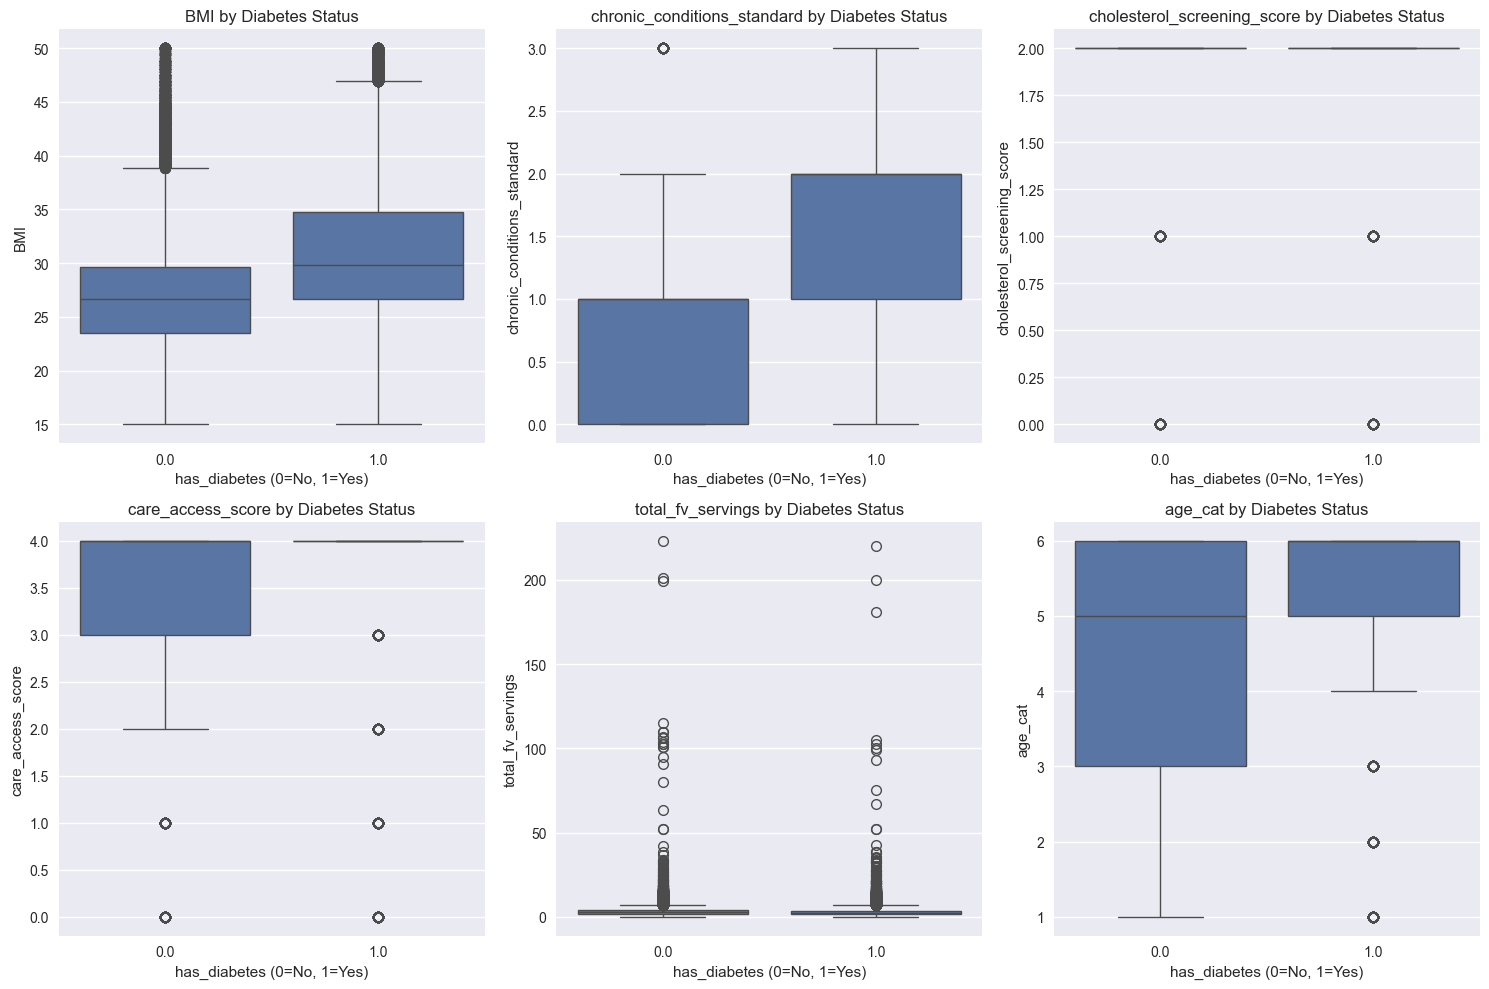

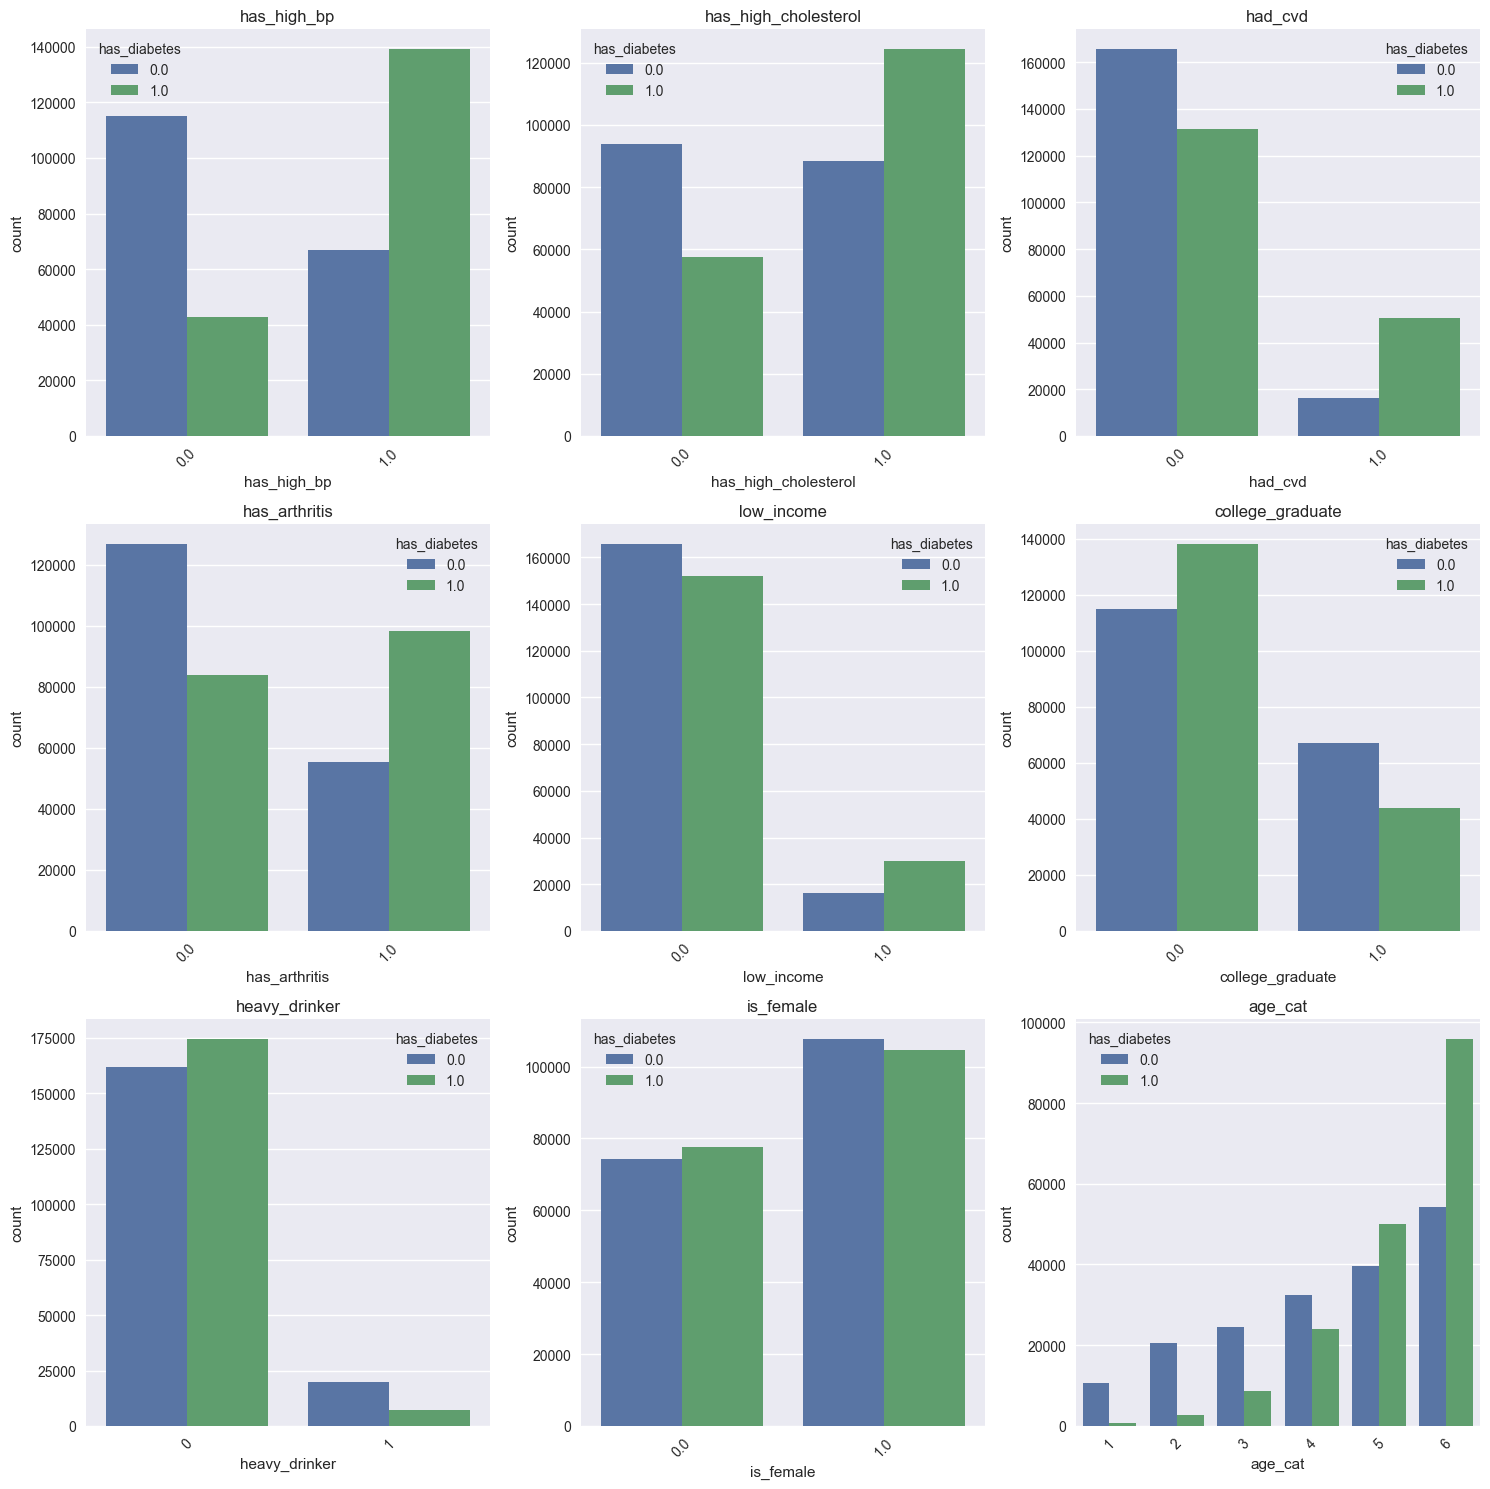

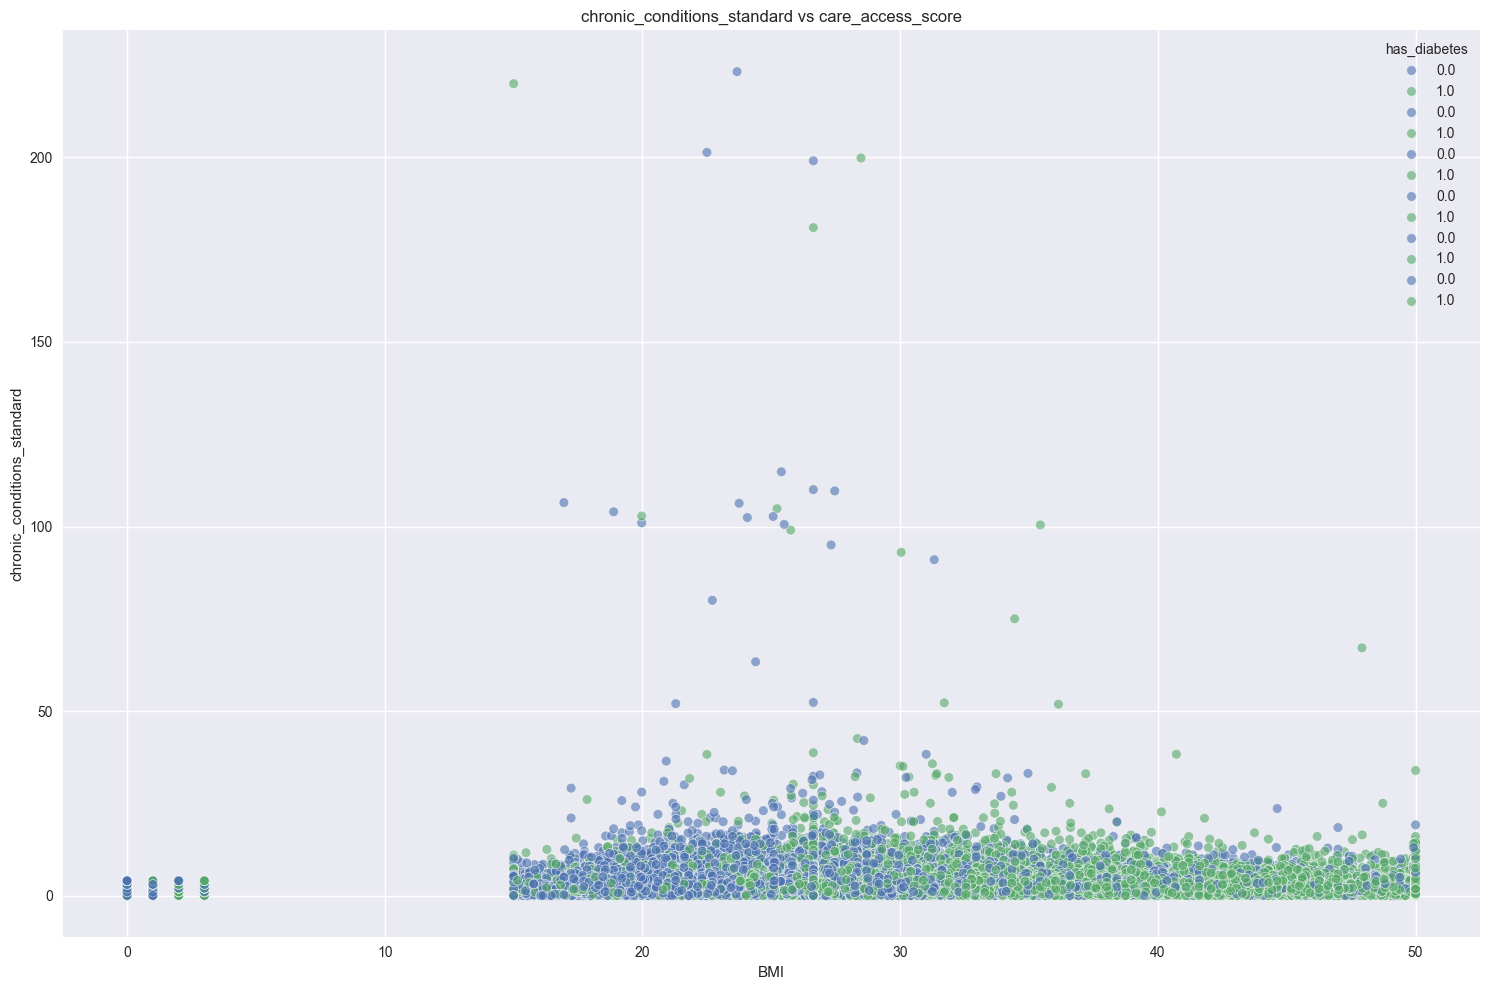


=== Continuous Feature Summary (by Diabetes Status) ===
has_diabetes                          0.0    1.0
BMI                         mean    27.13  31.13
                            median  26.63  29.86
                            std      5.41   6.63
chronic_conditions_standard mean     0.84   1.50
                            median   1.00   2.00
                            std      0.74   0.76
cholesterol_screening_score mean     1.70   1.94
                            median   2.00   2.00
                            std      0.69   0.32
care_access_score           mean     3.47   3.70
                            median   4.00   4.00
                            std      0.91   0.65
total_fv_servings           mean     2.89   2.66
                            median   2.68   2.43
                            std      2.26   2.06

Updated dataset saved to: ../data/processed/BRFSS_Diabetes_Visualized.csv


In [8]:

# Load data
df = pd.read_csv("../data/processed/BRFSS_Diabetes_Relevant_Features.csv")

selected_features = [
    # Numerical
    "chronic_conditions_standard",
    "age_cat",
    "BMI",
    "cholesterol_screening_score",
    "care_access_score",
    "total_activity_duration",   # ⚠️ High missingness
    "total_fv_servings",

    # Binary
    "has_high_bp",
    "has_high_cholesterol",
    "had_cvd",
    "has_arthritis",
    "low_income",
    "college_graduate",
    "heavy_drinker",
    "is_female"
]

target = "has_diabetes"

# Verify features and target
available_features = [col for col in selected_features if col in df.columns]
missing_features = [col for col in selected_features if col not in df.columns]
if missing_features:
    print(f"Warning: The following features are not in the dataset and will be skipped: {missing_features}")
if target not in df.columns:
    raise ValueError(f"Target column '{target}' not found in dataset.")
if not available_features:
    raise ValueError("No selected features are available in the dataset.")

df_analysis = df[available_features + [target]].copy()

print("Dataset shape:", df_analysis.shape)
print("\nNull values per column:")
null_counts = df_analysis.isnull().sum()
print(null_counts)

# Define feature types (update based on actual data semantics)
binary_features = [
    'has_high_bp', 'has_high_cholesterol', 'had_cvd', 'has_arthritis',
    'low_income', 'college_graduate', 'heavy_drinker', 'is_female'
]

categorical_features = ['age_cat']  # treated as ordinal
continuous_features = [
    'BMI', 'chronic_conditions_standard',
    'cholesterol_screening_score', 'care_access_score',
    'total_activity_duration', 'total_fv_servings'
]

# Filter to available
binary_features = [col for col in binary_features if col in available_features]
categorical_features = [col for col in categorical_features if col in available_features]
continuous_features = [col for col in continuous_features if col in available_features]

# --- LOGICAL IMPUTATION STRATEGY ---
print("\nApplying CDC/BRFSS-aligned imputation...")

# 1. Handle high-missingness variables: total_activity_duration (>60% missing)
#    → DO NOT IMPUTE. Instead, create a flag and set missing to a neutral value (e.g., 0)
#    BUT only if scientifically justifiable. In BRFSS, missing activity often = not reported,
#    not zero. So safer: drop or keep missing as NaN and exclude from modeling.
#    However, since you need a complete dataset, we'll:
#      - Create indicator: 'activity_reported'
#      - Impute missing with MEDIAN of reported values (not overall median) — but only if <50% missing.
#    But 63% is too high → **we will DROP this column** for modeling safety.

if 'total_activity_duration' in df_analysis.columns:
    missing_pct = df_analysis['total_activity_duration'].isnull().mean()
    if missing_pct > 0.5:
        print(f"  • total_activity_duration: {missing_pct:.1%} missing → DROPPING due to excessive missingness (per CDC best practices)")
        df_analysis = df_analysis.drop(columns=['total_activity_duration'])
        # Remove from feature lists
        if 'total_activity_duration' in continuous_features:
            continuous_features.remove('total_activity_duration')
        if 'total_activity_duration' in available_features:
            available_features.remove('total_activity_duration')

# 2. Impute remaining variables with <30% missing
cols_to_impute = [col for col in available_features if df_analysis[col].isnull().sum() > 0]

for col in cols_to_impute:
    missing_pct = df_analysis[col].isnull().mean()
    if missing_pct > 0.3:
        print(f"  • {col}: {missing_pct:.1%} missing → WARNING: High missingness, but proceeding with mode/median")
    
    if col in binary_features or col in categorical_features:
        # For binary/categorical: use mode
        mode_val = df_analysis[col].mode()
        if len(mode_val) > 0:
            fill_val = mode_val[0]
        else:
            fill_val = 0  # fallback
        df_analysis[col] = df_analysis[col].fillna(fill_val)
        print(f"  • {col}: Imputed with mode ({fill_val}) [missing: {missing_pct:.1%}]")
    elif col in continuous_features:
        # For continuous: use median (robust to outliers)
        median_val = df_analysis[col].median()
        df_analysis[col] = df_analysis[col].fillna(median_val)
        print(f"  • {col}: Imputed with median ({median_val:.2f}) [missing: {missing_pct:.1%}]")

# Final null check
print("\nNull values after imputation:")
print(df_analysis.isnull().sum())

# Update feature lists after potential drop
numerical_cols = continuous_features + categorical_features
binary_categorical_cols = binary_features + categorical_features

print(f"\nNumerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"Binary/Categorical features ({len(binary_categorical_cols)}): {binary_categorical_cols}")

# --- VISUALIZATIONS (same as before) ---
plt.style.use('seaborn-v0_8')

# Boxplots
if numerical_cols:
    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    plt.figure(figsize=(15, 5 * n_rows))
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.boxplot(data=df_analysis, x=target, y=col)
        plt.title(f'{col} by Diabetes Status')
        plt.xlabel('has_diabetes (0=No, 1=Yes)')
        plt.ylabel(col)
    for j in range(i + 1, n_rows * n_cols + 1):
        plt.subplot(n_rows, n_cols, j)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Countplots
if binary_categorical_cols:
    n_cols = 3
    n_rows = (len(binary_categorical_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_rows * n_cols > 1 else [axes]
    for idx, col in enumerate(binary_categorical_cols):
        sns.countplot(data=df_analysis, x=col, hue=target, ax=axes[idx])
        axes[idx].set_title(f'{col}')
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].legend(title='has_diabetes')
    for j in range(len(binary_categorical_cols), len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

# Scatterplots (only if ≥2 continuous features remain)
if len(continuous_features) >= 2:
    feature_pairs = list(combinations(continuous_features, 2))[:6]
    if feature_pairs:
        n_cols = 3
        n_rows = (len(feature_pairs) + n_cols - 1) // n_cols
        plt.figure(figsize=(15, 5 * n_rows))
        for i, (x, y) in enumerate(feature_pairs, 1):
            sns.scatterplot(data=df_analysis, x=x, y=y, hue=target, alpha=0.6)
            plt.title(f'{x} vs {y}')
            plt.legend(title='has_diabetes')
        for j in range(i + 1, n_rows * n_cols + 1):
            plt.subplot(n_rows, n_cols, j)
            plt.axis('off')
        plt.tight_layout()
        plt.show()

# Summary stats
if continuous_features:
    print("\n=== Continuous Feature Summary (by Diabetes Status) ===")
    summary_stats = df_analysis.groupby(target)[continuous_features].agg(['mean', 'median', 'std']).round(2)
    print(summary_stats.T)

# Save
output_path = "../data/processed/BRFSS_Diabetes_Visualized.csv"
df_analysis.to_csv(output_path, index=False)
print(f"\nUpdated dataset saved to: {output_path}")

In [9]:

# Load the cleaned dataset
input_path = '../data/processed/BRFSS_Diabetes_Visualized.csv'
df = pd.read_csv(input_path)
print(f"Loaded dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# Define target and features
target = 'has_diabetes'
features = [col for col in df.columns if col != target]

# Split features and target
X = df[features]
y = df[target]

# Perform train-test split (80-20 split, stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Combine features and target back into DataFrames
train_df = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
test_df = pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)

# Create output directory
output_dir = '../data/train-test/'
os.makedirs(output_dir, exist_ok=True)

# Save preprocessed train and test sets
train_df.to_csv(os.path.join(output_dir, 'train_set.csv'), index=False)
test_df.to_csv(os.path.join(output_dir, 'test_set.csv'), index=False)

# Print diagnostics
print(f"\nTrain set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")

print(f"\nTrain class distribution:")
print((y_train.value_counts(normalize=True) * 100).map('{:.2f}%'.format))

print(f"\nTest class distribution:")
print((y_test.value_counts(normalize=True) * 100).map('{:.2f}%'.format))

print(f"\nTrain and test sets saved to:")
print(f"   {os.path.join(output_dir, 'train_set.csv')}")
print(f"   {os.path.join(output_dir, 'test_set.csv')}")



Loaded dataset: 364,124 rows, 15 columns

Train set shape: (291299, 15)
Test set shape: (72825, 15)

Train class distribution:
has_diabetes
1.0    50.00%
0.0    50.00%
Name: proportion, dtype: object

Test class distribution:
has_diabetes
0.0    50.00%
1.0    50.00%
Name: proportion, dtype: object

Train and test sets saved to:
   ../data/train-test/train_set.csv
   ../data/train-test/test_set.csv
